# NB02 — Competitive Intelligence
**Project:** IMADATA Market Intelligence Framework — Mexico

**Research Objective 2:** Map competitor density and quantify competitive intensity at state and municipality level within Mexico's professional, scientific, and technical services sector (NAICS 541).

**Competitor universe:** Firms registered under NAICS sector 541 in DENUE. Classified into Direct (closest to IMADATA's service offering), Indirect (adjacent services), and Excluded (clearly outside scope).

**Competitive intensity** is operationally defined as a composite of three measures:
- **Density** — number of competitor firms per state / municipality
- **Concentration** — HHI across activity types within each state
- **Entry rate** — CAGR of competitor registrations from first to latest DENUE version snapshot

**Outputs produced:**
- `outputs/state_competitive_intensity.csv` — normalised competitive intensity score per state (feeds NB03)
- `outputs/municipality_hotspots.csv` — municipality-level competitor hotspot classification
- `outputs/competitors_filtered.csv` — cleaned, classified competitor dataset

---
> **Note on geography:** Analysis is conducted at state and municipality level using DENUE administrative codes. Metropolitan zones (ZMVMs) span multiple municipalities and are not constructed here; municipality-level analysis is the finest granularity available in the dataset.

## 0 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import requests
import re
import warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = Path('.')
OUT_DIR  = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)

COMPETITORS_FILE   = DATA_DIR / 'Competitors_raw_data.csv'
ACTIVITIES_FILE    = DATA_DIR / 'Competitors_activities.csv'
GEO_FILE           = DATA_DIR / 'General_state_muncipality.csv'
OVERRIDE_FILE      = DATA_DIR / 'activity_type_overrides.csv'

# ── Competitor classification keyword rules ───────────────────────────────────
# Ordered list: first match wins. Rules are auditable and can be refined via
# the override CSV without touching this code.
CLASSIFICATION_RULES = [
    ('Direct',
     r'\b(computer systems design|data processing|data analysis|business intelligence|'
     r'analytics|management consulting|consultor.a en administraci.n|'
     r'other scientific and technical consulting|'
     r'scientific research and development|market research|'
     r'investigaci.n de mercados|engineering services|testing laboratories)\b'),

    ('Indirect',
     r'\b(advertising|publicidad|graphic design|dise.o gr.fico|'
     r'public relations|web design|dise.o web|'
     r'architectural services|interior design|industrial design|'
     r'landscape architecture|translation|photography|'
     r'geophysical survey|map making|drawing services|building inspection)\b'),

    ('Exclude',
     r'\b(law firm|notary|notarial|accounting|auditing|contabilidad|auditor.a|'
     r'veterinary|fotograf.a|support services for carrying out legal)\b')
]

print('Config set.')

Config set.


---
## 1 · Data Loading & Merging

In [3]:
competitors_raw = pd.read_csv(COMPETITORS_FILE, low_memory=False)
activities      = pd.read_csv(ACTIVITIES_FILE)
geo             = pd.read_csv(GEO_FILE)

print(f'Competitors raw : {competitors_raw.shape[0]:>8,} rows  ×  {competitors_raw.shape[1]} columns')
print(f'Activities      : {activities.shape[0]:>8,} rows  ×  {activities.shape[1]} columns')
print(f'Geo lookup      : {geo.shape[0]:>8,} rows  ×  {geo.shape[1]} columns')

Competitors raw :   51,600 rows  ×  15 columns
Activities      :       41 rows  ×  3 columns
Geo lookup      :    1,885 rows  ×  4 columns


In [4]:
def standardise_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    return df


competitors_raw = standardise_cols(competitors_raw)
activities      = standardise_cols(activities)
geo             = standardise_cols(geo)

# Remove exact duplicates
n_before = len(competitors_raw)
competitors_raw = competitors_raw.drop_duplicates()
print(f'Duplicates removed: {n_before - len(competitors_raw):,}')

# Parse dates
competitors_raw['version']           = pd.to_datetime(competitors_raw['version'],           errors='coerce')
competitors_raw['registration_date'] = pd.to_datetime(competitors_raw['registration_date'], errors='coerce')

# Merge activity names
merged = competitors_raw.merge(activities, on='activity_code', how='left')

# Merge state and municipality names
merged = merged.merge(
    geo[['state_code','municipality_code','state_name','municipality_name']],
    on=['state_code','municipality_code'],
    how='left'
)

print(f'Merged dataset  : {merged.shape[0]:,} rows  ×  {merged.shape[1]} columns')
merged.head(3)

Duplicates removed: 0
Merged dataset  : 51,600 rows  ×  19 columns


,id,version,company_name,activity_code,employees,postal_code,state_code,municipality_code,phone,email,website,business_type,latitude,longitude,registration_date,activity_name_spanish,activity_name,state_name,municipality_name
0,10112,2019-04-01,ESTUDIO FOTOGRAFICO,541920,0-5,0,1,1,NaN,NaN,NaN,Permanent,21.8871,-102.2497,2010-07-01,Servicios de fotografia y videograbacion,Photography and video recording services,AGUASCALIENTES,AGUASCALIENTES
1,20316,2018-03-01,CORREDURIA PABLICA NAMERO 7,541120,0-5,0,1,1,"4,499,165,335.0000",CORREDURIA_PUBLICA07@YAHOO.COM,NaN,Permanent,21.8786,-102.2793,NaT,Notarias publicas,Notaries public,AGUASCALIENTES,AGUASCALIENTES
2,20316,2016-10-01,CORREDURIA PABLICA NAMERO 7,541120,0-5,0,1,1,"44,991,653,350.0000",CORREDURIA_PUBLICA07@YAHOO.COM,NaN,Permanent,21.8786,-102.2793,NaT,Notarias publicas,Notaries public,AGUASCALIENTES,AGUASCALIENTES


In [5]:
missing = merged.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
display(pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : (missing / len(merged) * 100).round(1)
}))

,Missing Count,Missing %
website,46186,89.5000
email,34518,66.9000
phone,24390,47.3000
registration_date,11676,22.6000


---
## 2 · Competitor Classification (Direct / Indirect / Exclude)

Classification logic applies keyword rules against the English `activity_name` field. An auditable override CSV (`activity_type_overrides.csv`) is generated on first run — edit it manually to correct any misclassifications, then re-run this section.

In [6]:
def classify_activity(name: str) -> str:
    """Apply ordered keyword rules; return 'Uncertain' if no rule matches."""
    name_lower = str(name).lower()
    for label, pattern in CLASSIFICATION_RULES:
        if re.search(pattern, name_lower):
            return label
    return 'Uncertain'


# Build activity-level mapping
activity_map = (
    merged[['activity_code','activity_name']]
      .drop_duplicates('activity_code')
      .copy()
)
activity_map['competitor_type_auto'] = activity_map['activity_name'].apply(classify_activity)

# ── Override CSV pattern ──────────────────────────────────────────────────────
# On first run: write a seed file for manual review.
# On subsequent runs: load overrides and apply, allowing correction without code changes.
try:
    overrides = pd.read_csv(OVERRIDE_FILE)
    activity_map = activity_map.merge(
        overrides[['activity_code','competitor_type_final']],
        on='activity_code', how='left'
    )
    activity_map['competitor_type_final'] = (
        activity_map['competitor_type_final']
          .fillna(activity_map['competitor_type_auto'])
    )
    print(f'Override file loaded: {len(overrides)} entries applied.')

except FileNotFoundError:
    activity_map['competitor_type_final'] = activity_map['competitor_type_auto']
    seed = activity_map[['activity_code','activity_name','competitor_type_auto']].copy()
    seed.columns = ['activity_code','activity_name','competitor_type_final']
    seed.to_csv(OVERRIDE_FILE, index=False)
    print(f'Override file created: {OVERRIDE_FILE}')
    print('Edit "competitor_type_final" column and re-run this cell to apply corrections.')

print('\nClassification distribution:')
print(activity_map['competitor_type_final'].value_counts())

Override file loaded: 40 entries applied.

Classification distribution:
competitor_type_final
Indirect    25
Exclude      9
Direct       6
Name: count, dtype: int64


In [7]:
# Apply final type to row-level data
merged = merged.merge(
    activity_map[['activity_code','competitor_type_final']],
    on='activity_code', how='left'
)

# Keep only Direct and Indirect for all downstream analysis
competitors = merged[
    merged['competitor_type_final'].isin(['Direct', 'Indirect'])
].copy().reset_index(drop=True)

print(f'Filtered to Direct + Indirect: {len(competitors):,} rows')
print(competitors['competitor_type_final'].value_counts())

Filtered to Direct + Indirect: 21,544 rows
competitor_type_final
Indirect    14488
Direct       7056
Name: count, dtype: int64


In [8]:
# Direct vs Indirect composition
type_counts = competitors['competitor_type_final'].value_counts().reset_index()
type_counts.columns = ['competitor_type', 'count']

fig = px.pie(
    type_counts,
    names='competitor_type', values='count',
    title='Competitor Classification — Direct vs Indirect',
    color='competitor_type',
    color_discrete_map={'Direct': '#d6604d', 'Indirect': '#74add1'},
    hole=0.35
)
fig.show()

---
## 3 · Exploratory Data Analysis

In [9]:
# ── 3.1  Top activities among Direct competitors ──────────────────────────────
direct_acts = (
    competitors[competitors['competitor_type_final'] == 'Direct']
      ['activity_name'].value_counts()
      .head(15)
      .reset_index()
)
direct_acts.columns = ['activity_name', 'count']

fig = px.bar(
    direct_acts,
    x='count', y='activity_name',
    orientation='h',
    title='Top 15 Activity Types — Direct Competitors',
    labels={'activity_name': 'Activity', 'count': 'Number of Companies'},
    color='count',
    color_continuous_scale='Reds'
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_showscale=False,
    height=500
)
fig.show()

In [10]:
# ── 3.2  Competitor count by state ───────────────────────────────────────────
state_counts = (
    competitors.groupby('state_name')
               .size()
               .reset_index(name='company_count')
               .sort_values('company_count', ascending=False)
)

fig = px.bar(
    state_counts,
    x='state_name', y='company_count',
    title='Competitor Count by State (NAICS 541 — Direct + Indirect)',
    labels={'state_name': 'State', 'company_count': 'Number of Competitors'},
    color='company_count',
    color_continuous_scale='Reds'
)
fig.update_layout(xaxis_tickangle=-45, coloraxis_showscale=False)
fig.show()

In [11]:
# ── 3.3  Top 20 municipalities by competitor count ────────────────────────────
muni_counts = (
    competitors
      .groupby(['state_name','municipality_name'])
      .size()
      .reset_index(name='company_count')
      .sort_values('company_count', ascending=False)
)
muni_counts['label'] = muni_counts['municipality_name'] + ' (' + muni_counts['state_name'] + ')'

fig = px.bar(
    muni_counts.head(20),
    x='company_count', y='label',
    orientation='h',
    title='Top 20 Municipalities by Competitor Count',
    labels={'label': 'Municipality', 'company_count': 'Number of Competitors'},
    color='company_count',
    color_continuous_scale='Reds'
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_showscale=False,
    height=550
)
fig.show()

In [12]:
# ── 3.4  Digital presence of competitors ─────────────────────────────────────
competitors['has_website'] = (competitors['website'].notna() & (competitors['website'].str.strip() != '')).astype(int)
competitors['has_email']   = (competitors['email'].notna()   & (competitors['email'].str.strip()   != '')).astype(int)
competitors['digital_presence_score'] = competitors['has_website'] + competitors['has_email']

dp_labels = {0: 'None', 1: 'One Contact', 2: 'Both Website & Email'}
dp_dist = (
    competitors['digital_presence_score']
      .map(dp_labels)
      .value_counts()
      .reset_index()
)
dp_dist.columns = ['digital_presence', 'count']

fig = px.bar(
    dp_dist,
    x='digital_presence', y='count',
    title='Digital Presence of Competitor Firms',
    labels={'digital_presence': 'Digital Presence Level', 'count': 'Number of Companies'},
    color='digital_presence',
    color_discrete_sequence=['#d1e5f0','#74add1','#2166ac']
)
fig.update_layout(showlegend=False)
fig.show()

In [13]:
# ── 3.5  Temporal entry trend (registration by year) ─────────────────────────
reg_trend = (
    competitors.dropna(subset=['registration_date'])
               .assign(year=lambda x: x['registration_date'].dt.year)
               .query('2000 <= year <= 2024')
               .groupby('year')
               .size()
               .reset_index(name='registrations')
)

fig = px.line(
    reg_trend,
    x='year', y='registrations',
    title='Competitor Registrations Over Time (NAICS 541)',
    markers=True,
    labels={'year': 'Year', 'registrations': 'Registrations'}
)
fig.update_traces(line_color='#d6604d')
fig.show()

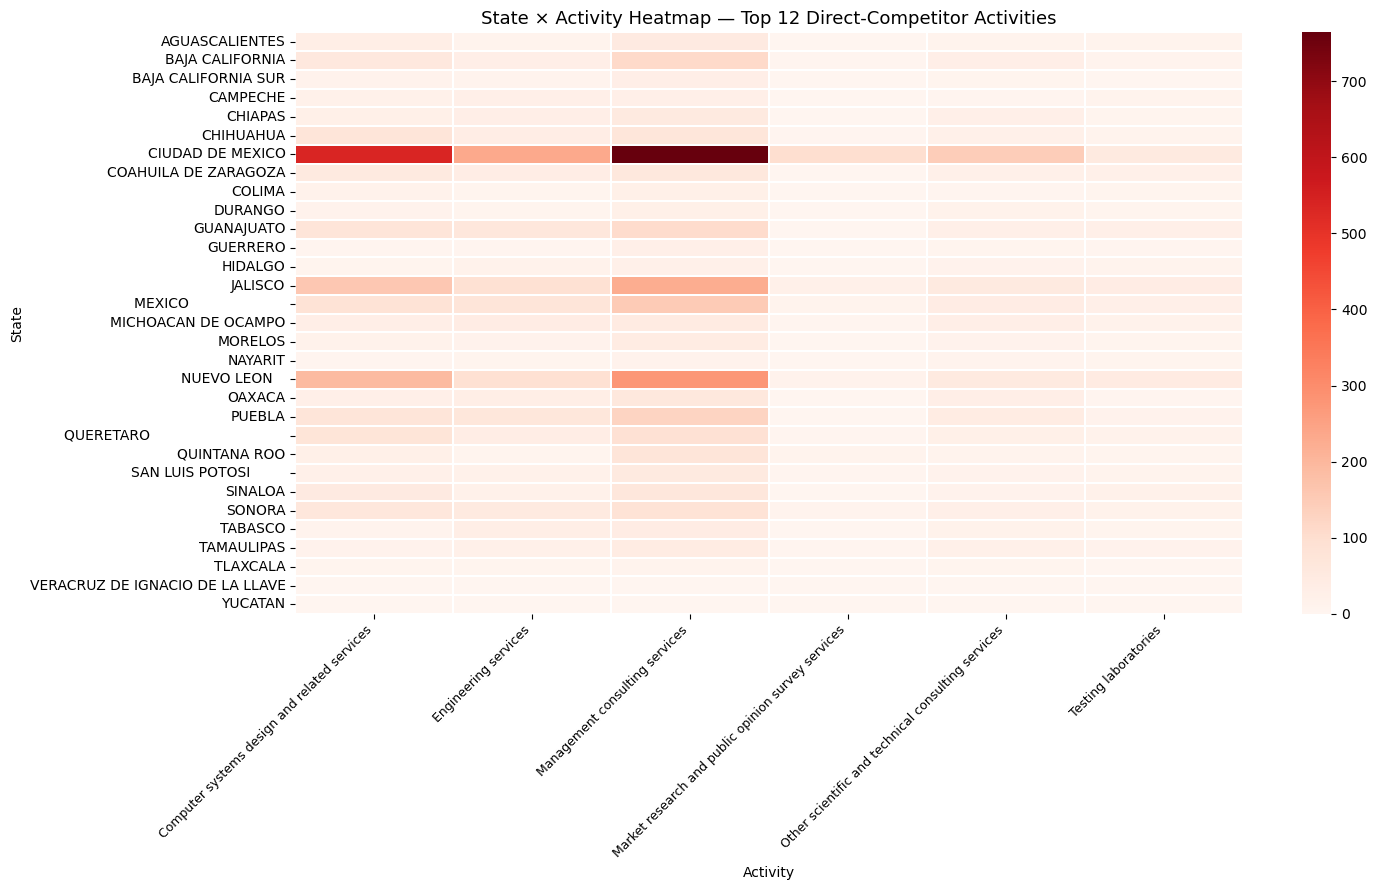

In [14]:
# ── 3.6  State × Activity heatmap (Direct competitors only) ──────────────────
N_TOP_ACTS = 12
top_acts = (
    competitors[competitors['competitor_type_final'] == 'Direct']
      ['activity_name'].value_counts()
      .head(N_TOP_ACTS).index
)

heat_df = (
    competitors[
        (competitors['competitor_type_final'] == 'Direct') &
        (competitors['activity_name'].isin(top_acts))
    ]
    .groupby(['state_name','activity_name'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

plt.figure(figsize=(15, 9))
sns.heatmap(heat_df, cmap='Reds', linewidths=0.2, annot=False)
plt.title(f'State × Activity Heatmap — Top {N_TOP_ACTS} Direct-Competitor Activities', fontsize=13)
plt.xlabel('Activity')
plt.ylabel('State')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

---
## 4 · Competitive Intensity Metrics

Four complementary metrics are computed at state level and combined into a single Competitive Intensity Index (CII):

| Metric | Weight | Measures |
|---|---|---|
| **Competitor density** | 0.45 | Raw count of Direct + Indirect competitors per state |
| **Gini coefficient** | 0.20 | Geographic concentration of competitors within a state |
| **HHI** | 0.20 | Activity-mix concentration (high = specialists, low = generalists) |
| **CAGR** | 0.15 | Competitor entry growth rate from first to last DENUE version |

> **Density dominates** because absolute market saturation is the most direct signal of entry difficulty. Gini captures within-state geographic structure — a high-Gini state has competitors clustered in one city, leaving other municipalities more open. HHI reflects specialisation depth; high HHI means competitors focus on one activity type and may be easier to displace in adjacent services. CAGR measures momentum.

> **Minimum competitor threshold:** States with fewer than 5 Direct competitors are excluded from the composite computation and assigned `competitive_intensity = 0`. Below this threshold, HHI trivially equals 1.0 (single activity), which would produce misleading CII values.


In [15]:
# ── HHI — activity-mix concentration within each state ───────────────────────
def hhi(counts: np.ndarray) -> float:
    """Herfindahl-Hirschman Index, normalised to 0–1."""
    total = counts.sum()
    if total == 0:
        return np.nan
    shares = counts / total
    return float(np.sum(shares ** 2))


state_act = (
    competitors
      .groupby(['state_name','activity_name'])
      .size()
      .reset_index(name='cnt')
)

hhi_activity = (
    state_act.groupby('state_name')['cnt']
             .apply(lambda s: hhi(s.to_numpy()))
             .reset_index(name='hhi_activity')
)

print('HHI (activity mix) — top 5 most concentrated states:')
display(hhi_activity.sort_values('hhi_activity', ascending=False).head(5))

HHI (activity mix) — top 5 most concentrated states:


,state_name,hhi_activity
31,ZACATECAS,1.0000
29,VERACRUZ DE IGNACIO DE LA LLAVE,0.2800
30,YUCATAN,0.2500
14,MEXICO,0.2485
28,TLAXCALA,0.2453


In [16]:
# ── Gini — geographic distribution within each state ─────────────────────────
def gini(counts: np.ndarray) -> float:
    """Gini coefficient from array of counts (0 = perfect equality, 1 = total concentration)."""
    x = np.sort(np.abs(counts))
    if x.sum() == 0:
        return np.nan
    n    = len(x)
    cumx = np.cumsum(x)
    return float((n + 1 - 2 * cumx.sum() / cumx[-1]) / n)


state_muni = (
    competitors
      .groupby(['state_name','municipality_name'])
      .size()
      .reset_index(name='cnt')
)

gini_geo = (
    state_muni.groupby('state_name')['cnt']
              .apply(lambda s: gini(s.to_numpy()))
              .reset_index(name='gini_geo')
)

print('Gini (geographic concentration) — top 5 most concentrated states:')
display(gini_geo.sort_values('gini_geo', ascending=False).head(5))

Gini (geographic concentration) — top 5 most concentrated states:


,state_name,gini_geo
0,AGUASCALIENTES,0.8407
18,NUEVO LEON,0.8377
13,JALISCO,0.8349
21,QUERETARO,0.8309
9,DURANGO,0.8256


In [17]:
# ── CAGR — competitor entry rate by state ─────────────────────────────────────
# Uses DENUE version timestamps (not registration_date) so the time window
# reflects the observation period of the dataset itself.

competitors['version_dt'] = pd.to_datetime(competitors['version'], errors='coerce')

state_time = (
    competitors
      .dropna(subset=['version_dt'])
      .groupby(['state_name','version_dt'])
      .size()
      .reset_index(name='cnt')
      .sort_values(['state_name','version_dt'])
)

first_last = (
    state_time
      .groupby('state_name', as_index=False)
      .agg(
          first_cnt=('cnt', 'first'),
          last_cnt =('cnt', 'last'),
          first_ver=('version_dt', 'first'),
          last_ver =('version_dt', 'last')
      )
)

first_last['years_elapsed'] = (
    (first_last['last_ver'] - first_last['first_ver']).dt.days / 365.25
)

def cagr(first, last, years):
    if pd.isna(years) or years <= 0 or first <= 0:
        return np.nan
    return (last / first) ** (1 / years) - 1

first_last['cagr'] = first_last.apply(
    lambda r: cagr(r['first_cnt'], r['last_cnt'], r['years_elapsed']), axis=1
)

# Only keep states with at least 2 distinct version snapshots
n_versions = (
    state_time.groupby('state_name')['version_dt']
              .nunique()
              .reset_index(name='n_versions')
)
cagr_df = first_last.merge(n_versions, on='state_name')
cagr_df = cagr_df[cagr_df['n_versions'] >= 2].copy()

print('CAGR — competitor entry rate:')
display(cagr_df[['state_name','first_cnt','last_cnt','years_elapsed','cagr']]
          .sort_values('cagr', ascending=False).head(10))

CAGR — competitor entry rate:


,state_name,first_cnt,last_cnt,years_elapsed,cagr
12,HIDALGO,17,42,8.8350,0.1078
16,MORELOS,10,22,8.8350,0.0933
19,OAXACA,25,53,8.8350,0.0888
0,AGUASCALIENTES,10,20,8.8350,0.0816
20,PUEBLA,56,105,8.8350,0.0737
3,CAMPECHE,7,13,8.8350,0.0726
23,SAN LUIS POTOSI,13,22,8.8350,0.0614
2,BAJA CALIFORNIA SUR,8,13,8.8350,0.0565
15,MICHOACAN DE OCAMPO,32,49,8.8350,0.0494
27,TAMAULIPAS,19,24,8.8350,0.0268


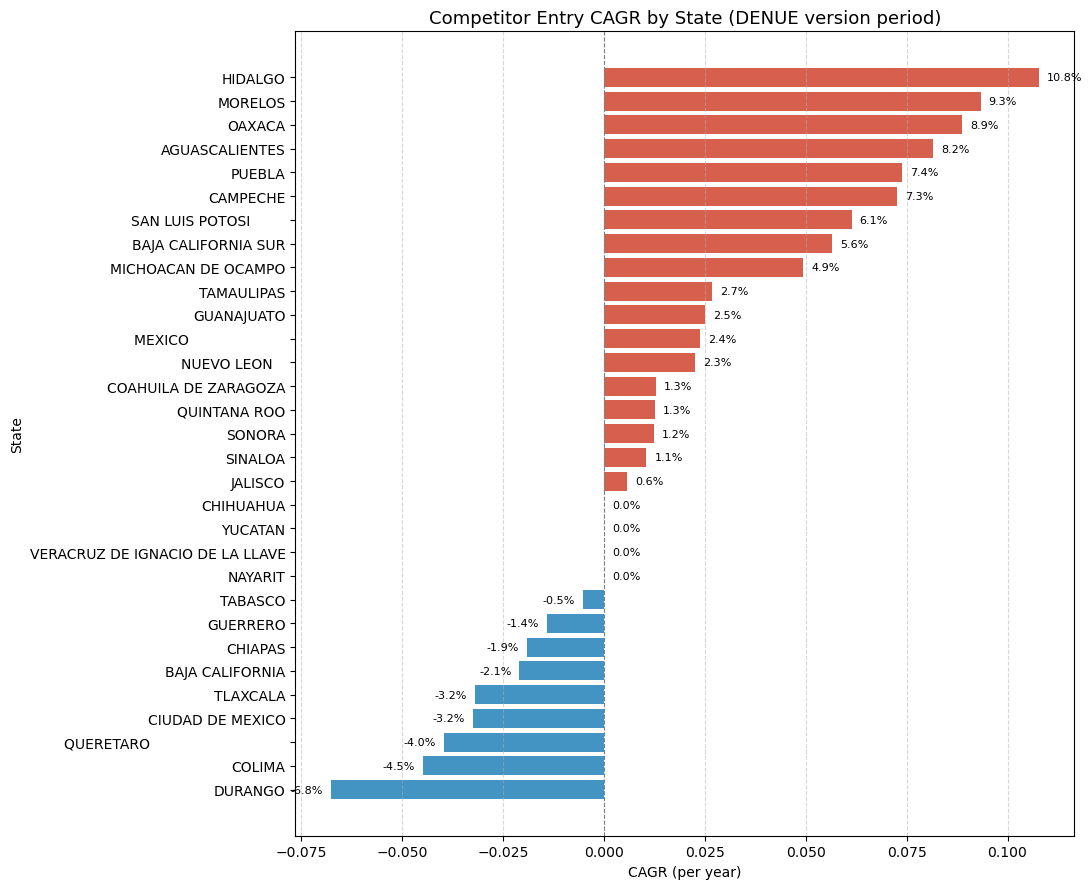

In [18]:
# CAGR diverging bar chart
cagr_plot = cagr_df.sort_values('cagr').copy()
cagr_plot['cagr_label'] = (cagr_plot['cagr'] * 100).map('{:.1f}%'.format)
cagr_plot['color'] = cagr_plot['cagr'].apply(lambda x: '#d6604d' if x > 0 else '#4393c3')

fig, ax = plt.subplots(figsize=(11, 9))
bars = ax.barh(
    cagr_plot['state_name'],
    cagr_plot['cagr'],
    color=cagr_plot['color']
)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')

for bar, label, val in zip(bars, cagr_plot['cagr_label'], cagr_plot['cagr']):
    offset = 0.002 if val >= 0 else -0.002
    ha     = 'left'  if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            label, va='center', ha=ha, fontsize=8)

ax.set_title('Competitor Entry CAGR by State (DENUE version period)', fontsize=13)
ax.set_xlabel('CAGR (per year)')
ax.set_ylabel('State')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

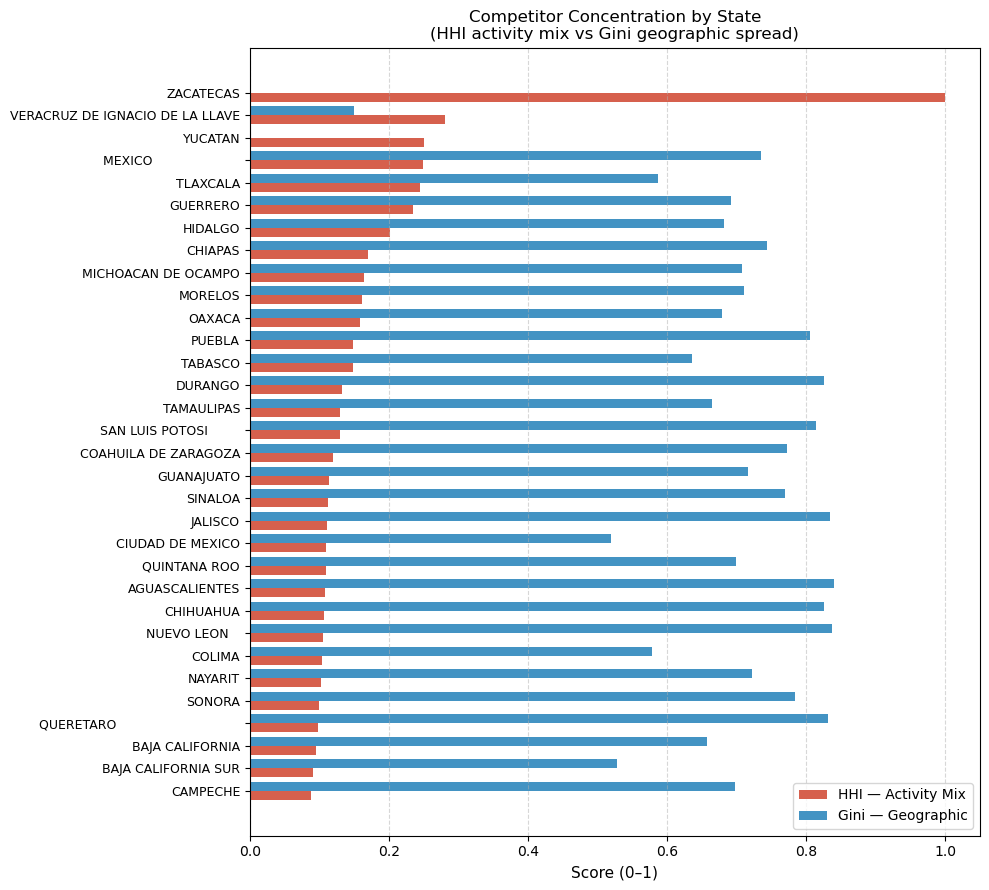

In [19]:
# HHI dual-metric bar chart
hhi_full = hhi_activity.merge(gini_geo, on='state_name', how='inner')
hhi_sorted = hhi_full.sort_values('hhi_activity', ascending=True)

y_pos   = np.arange(len(hhi_sorted))
bar_w   = 0.4

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(y_pos - bar_w/2, hhi_sorted['hhi_activity'], height=bar_w,
        color='#d6604d', label='HHI — Activity Mix')
ax.barh(y_pos + bar_w/2, hhi_sorted['gini_geo'],    height=bar_w,
        color='#4393c3', label='Gini — Geographic')

ax.set_yticks(y_pos)
ax.set_yticklabels(hhi_sorted['state_name'], fontsize=9)
ax.set_xlabel('Score (0–1)', fontsize=11)
ax.set_title('Competitor Concentration by State\n(HHI activity mix vs Gini geographic spread)', fontsize=12)
ax.legend()
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## 5 · Competitive Intensity Index (Composite Score per State)

All three metrics are combined into a single Competitive Intensity Index (CII) per state.
Each component is min-max normalised to 0–1 before weighting so that differences in scale do not dominate the score.

| Component | Weight | Rationale |
|---|---|---|
| Normalised density | 0.50 | Most direct measure of competitive pressure |
| HHI | 0.25 | Structural concentration — concentrated markets are harder to enter |
| CAGR | 0.25 | Forward-looking — fast-growing competitor bases signal increasing pressure |

In [20]:
def minmax(s: pd.Series) -> pd.Series:
    lo, hi = s.min(), s.max()
    if hi == lo:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - lo) / (hi - lo)


# ── Minimum competitor threshold ──────────────────────────────────────────────
# States with fewer than 5 Direct competitors are excluded from the CII.
# With very few firms, HHI trivially reaches 1.0 (all activity in one code),
# which would dominate the composite and misrepresent true competitive intensity.
# These states are assigned competitive_intensity = 0 (no meaningful competition).
MIN_COMPETITORS = 5

density = state_counts.rename(columns={'company_count': 'density'})
density_filtered = density[density['density'] >= MIN_COMPETITORS].copy()

low_competition_states = density[density['density'] < MIN_COMPETITORS]['state_name'].tolist()
if low_competition_states:
    print(f'States below min-competitor threshold (CII set to 0): {low_competition_states}')

# ── Assemble CII components ───────────────────────────────────────────────────
cii = (
    density_filtered
      .merge(hhi_activity, on='state_name', how='left')
      .merge(gini_geo,     on='state_name', how='left')
      .merge(cagr_df[['state_name','cagr']], on='state_name', how='left')
)

# Fill missing CAGR with 0 (states with only one version snapshot)
cii['cagr'] = cii['cagr'].fillna(0)

# Normalise each component 0–1
cii['density_norm'] = minmax(cii['density'])
cii['hhi_norm']     = minmax(cii['hhi_activity'])
cii['gini_norm']    = minmax(cii['gini_geo'])
cii['cagr_norm']    = minmax(cii['cagr'])

# ── Weighted composite ────────────────────────────────────────────────────────
# Weights rationale:
#   density (0.45): absolute number of competitors is the strongest signal
#                   of market saturation IMADATA will face on entry
#   gini (0.20):    geographic concentration — a high-gini state concentrates
#                   competitors in one city, leaving other municipalities open
#   hhi (0.20):     activity-mix concentration — low HHI means competitors
#                   span many services, high HHI means they specialise (easier to undercut)
#   cagr (0.15):    momentum — fast-growing competitor bases signal attractive
#                   but increasingly crowded markets
cii['competitive_intensity'] = (
    cii['density_norm'] * 0.45 +
    cii['gini_norm']    * 0.20 +
    cii['hhi_norm']     * 0.20 +
    cii['cagr_norm']    * 0.15
).round(4)

# ── Add excluded states back with intensity = 0 ───────────────────────────────
if low_competition_states:
    excluded = pd.DataFrame({
        'state_name': low_competition_states,
        'density': 0,
        'competitive_intensity': 0.0
    })
    cii = pd.concat([cii, excluded], ignore_index=True).fillna(0)

cii = cii.sort_values('competitive_intensity', ascending=False).reset_index(drop=True)

print('Top 10 states by competitive intensity:')
display(cii[['state_name','density','hhi_activity','gini_geo','cagr','competitive_intensity']].head(10))


States below min-competitor threshold (CII set to 0): ['YUCATAN', 'ZACATECAS']
Top 10 states by competitive intensity:


,state_name,density,hhi_activity,gini_geo,cagr,competitive_intensity
0,MEXICO,2264,0.2485,0.7344,0.0239,0.6585
1,CIUDAD DE MEXICO,4174,0.1101,0.5193,-0.0323,0.6101
2,PUEBLA,1232,0.1486,0.8050,0.0737,0.5061
3,JALISCO,1811,0.1112,0.8349,0.0058,0.4802
4,HIDALGO,452,0.2012,0.6820,0.1078,0.4702
5,NUEVO LEON,1335,0.1059,0.8377,0.0226,0.4385
6,MICHOACAN DE OCAMPO,809,0.1636,0.7078,0.0494,0.4271
7,OAXACA,625,0.1584,0.6787,0.0888,0.4271
8,MORELOS,347,0.1620,0.7101,0.0933,0.4138
9,GUERRERO,325,0.2351,0.6915,-0.0141,0.3904


In [21]:
fig = px.bar(
    cii,
    x='competitive_intensity', y='state_name',
    orientation='h',
    title='Competitive Intensity Index by State (normalised 0–1)',
    labels={'competitive_intensity': 'CII Score', 'state_name': 'State'},
    color='competitive_intensity',
    color_continuous_scale='Reds'
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_showscale=False,
    height=700
)
fig.show()

---
## 6 · Municipality-Level Clustering — Hotspot Detection

In [22]:
# Build municipality × activity feature matrix (Direct competitors only)
N_TOP = 15
top_direct = (
    competitors[competitors['competitor_type_final'] == 'Direct']
      ['activity_name'].value_counts()
      .head(N_TOP).index
)

muni_feat = (
    competitors[
        (competitors['competitor_type_final'] == 'Direct') &
        (competitors['activity_name'].isin(top_direct))
    ]
    .groupby(['state_name','municipality_name','activity_name'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

muni_feat['total_direct'] = muni_feat[top_direct].sum(axis=1)

print(f'Municipality feature matrix: {muni_feat.shape}')
muni_feat.head(3)

Municipality feature matrix: (426, 9)


activity_name,state_name,municipality_name,Computer systems design and related services,Engineering services,Management consulting services,Market research and public opinion survey services,Other scientific and technical consulting services,Testing laboratories,total_direct
0,AGUASCALIENTES,AGUASCALIENTES,32,8,49,1,10,8,108
1,AGUASCALIENTES,JESUS MARIA,2,2,1,0,0,2,7
2,BAJA CALIFORNIA,ENSENADA,3,6,12,0,3,0,24


In [23]:
feat_cols = top_direct.tolist() + ['total_direct']
X_muni    = muni_feat[feat_cols].values
X_scaled  = StandardScaler().fit_transform(X_muni)

# ── Select k via Calinski-Harabasz (more robust for count-based features) ─────
K_RANGE_MUNI = range(2, 9)
ch_muni      = []
for k in K_RANGE_MUNI:
    km     = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = km.fit_predict(X_scaled)
    ch_muni.append(calinski_harabasz_score(X_scaled, labels))

optimal_k_muni = max(list(K_RANGE_MUNI)[int(np.argmax(ch_muni))], 3)
print(f'Optimal k for municipality clustering (CH): {optimal_k_muni}')

km_final = KMeans(n_clusters=optimal_k_muni, n_init='auto', random_state=42)
muni_feat['cluster'] = km_final.fit_predict(X_scaled)

# Identify hotspot cluster: highest mean total_direct
cluster_avg     = muni_feat.groupby('cluster')['total_direct'].mean()
hotspot_cluster = cluster_avg.idxmax()
muni_feat['is_hotspot'] = muni_feat['cluster'] == hotspot_cluster

print(f'\nHotspot municipalities (top-density cluster): {muni_feat["is_hotspot"].sum():,}')
print(f'Non-hotspot                                   : {(~muni_feat["is_hotspot"]).sum():,}')
print(f'\nCluster mean total_direct:')
print(cluster_avg.sort_values(ascending=False).round(1))


NameError: name 'calinski_harabasz_score' is not defined

In [ ]:
# Top hotspot municipalities
top_hotspots = (
    muni_feat[muni_feat['is_hotspot']]
      .nlargest(15, 'total_direct')
      .copy()
)
top_hotspots['label'] = (
    top_hotspots['municipality_name'] + ' (' + top_hotspots['state_name'] + ')'
)

fig = px.bar(
    top_hotspots,
    x='total_direct', y='label',
    orientation='h',
    title='Top 15 Competitor Hotspot Municipalities (Direct Competitors)',
    labels={'total_direct': 'Direct Competitors', 'label': 'Municipality'},
    color='total_direct',
    color_continuous_scale='Reds'
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_showscale=False,
    height=550
)
fig.show()

---
## 7 · Export Outputs

In [ ]:
# ── State competitive intensity → feeds NB03 ──────────────────────────────────
cii_export = cii[[
    'state_name',
    'density', 'hhi_activity', 'gini_geo', 'cagr',
    'density_norm', 'hhi_norm', 'cagr_norm',
    'competitive_intensity'
]].copy()
cii_export.to_csv(OUT_DIR / 'state_competitive_intensity.csv', index=False)

# ── Municipality hotspots ─────────────────────────────────────────────────────
muni_feat.to_csv(OUT_DIR / 'municipality_hotspots.csv', index=False)

# ── Filtered & classified competitor dataset ─────────────────────────────────
competitors.to_csv(OUT_DIR / 'competitors_filtered.csv', index=False)

print('Outputs saved to outputs/')
print(f'  state_competitive_intensity.csv  —  {len(cii_export)} states')
print(f'  municipality_hotspots.csv        —  {len(muni_feat):,} municipalities')
print(f'  competitors_filtered.csv         —  {len(competitors):,} companies')

Outputs saved to outputs/
  state_competitive_intensity.csv  —  32 states
  municipality_hotspots.csv        —  442 municipalities
  competitors_filtered.csv         —  20,874 companies
